In [2]:
import os

input_dir = '/kaggle/input/datasets/tvnam2712/cauvangbanlaohac-iwildcam-v2' 
print(os.listdir(input_dir))

archive_dir = os.path.join(input_dir, 'archive')
if os.path.exists(archive_dir):
    print("Child directory within the archive:", os.listdir(archive_dir)[:5])

['categories.csv', 'RELEASE_v2.0.txt', 'iwildcam2021_train_annotations_final.json', 'metadata.csv', 'archive']
Child directory within the archive: ['categories.csv', 'RELEASE_v2.0.txt', 'iwildcam2021_train_annotations_final.json', 'metadata.csv', 'train']


In [4]:
import pandas as pd
metadata_path = input_dir + "/archive/metadata.csv"

df_metadata = pd.read_csv(metadata_path)
df_metadata

,Unnamed: 0,split,location_remapped,location,sequence_remapped,seq_id,y,category_id,datetime,filename,image_id
0,0,id_test,2,3,2124,300484b8-7d42-11eb-8fb5-0242ac1c0002,1,2,2013-06-01 06:55:00.000,97f407ac-21bc-11ea-a13a-137349068a90.jpg,97f407ac-21bc-11ea-a13a-137349068a90
1,1,id_test,2,3,2124,300484b8-7d42-11eb-8fb5-0242ac1c0002,1,2,2013-06-01 06:55:01.000,954d7740-21bc-11ea-a13a-137349068a90.jpg,954d7740-21bc-11ea-a13a-137349068a90
2,2,id_test,2,3,2124,300484b8-7d42-11eb-8fb5-0242ac1c0002,1,2,2013-06-01 06:55:02.000,86b3a4fc-21bc-11ea-a13a-137349068a90.jpg,86b3a4fc-21bc-11ea-a13a-137349068a90
3,3,id_test,2,3,2124,300484b8-7d42-11eb-8fb5-0242ac1c0002,1,2,2013-06-01 06:55:03.000,90a74fea-21bc-11ea-a13a-137349068a90.jpg,90a74fea-21bc-11ea-a13a-137349068a90
4,4,id_test,2,3,2124,300484b8-7d42-11eb-8fb5-0242ac1c0002,1,2,2013-06-01 06:55:04.000,88f81d24-21bc-11ea-a13a-137349068a90.jpg,88f81d24-21bc-11ea-a13a-137349068a90
...,...,...,...,...,...,...,...,...,...,...,...
203024,203024,val,320,547,4924,300de60c-7d42-11eb-8fb5-0242ac1c0002,145,371,2013-08-02 10:34:56.000,94bd7c44-21bc-11ea-a13a-137349068a90.jpg,94bd7c44-21bc-11ea-a13a-137349068a90
203025,203025,val,320,547,4924,300de60c-7d42-11eb-8fb5-0242ac1c0002,145,371,2013-08-02 10:34:57.000,96d2be0e-21bc-11ea-a13a-137349068a90.jpg,96d2be0e-21bc-11ea-a13a-137349068a90
203026,203026,val,320,547,4924,300de60c-7d42-11eb-8fb5-0242ac1c0002,145,371,2013-08-02 10:34:57.000,9630ac0e-21bc-11ea-a13a-137349068a90.jpg,9630ac0e-21bc-11ea-a13a-137349068a90
203027,203027,val,320,547,4924,300de60c-7d42-11eb-8fb5-0242ac1c0002,145,371,2013-08-02 10:34:58.000,9234e9ee-21bc-11ea-a13a-137349068a90.jpg,9234e9ee-21bc-11ea-a13a-137349068a90


In [5]:
categories_path = input_dir + '/archive/categories.csv'
df_categories = pd.read_csv(categories_path)
df_categories

,y,category_id,name
0,0,0,empty
1,1,2,tayassu pecari
2,2,3,dasyprocta punctata
3,3,4,cuniculus paca
4,4,6,puma concolor
...,...,...,...
201,99999,355,mesopicos griseocephalus
202,99999,412,erithacus cyane
203,99999,357,streptopelia lugens
204,99999,407,mustela lutreolina


In [6]:
df_merged = pd.merge(df_metadata, df_categories, on='category_id', how='left')

print("The data after combining:")
print(df_merged[['image_id', 'category_id', 'name']].head(10))

The data after combining:
                               image_id  category_id            name
0  97f407ac-21bc-11ea-a13a-137349068a90            2  tayassu pecari
1  954d7740-21bc-11ea-a13a-137349068a90            2  tayassu pecari
2  86b3a4fc-21bc-11ea-a13a-137349068a90            2  tayassu pecari
3  90a74fea-21bc-11ea-a13a-137349068a90            2  tayassu pecari
4  88f81d24-21bc-11ea-a13a-137349068a90            2  tayassu pecari
5  98e414ae-21bc-11ea-a13a-137349068a90            2  tayassu pecari
6  96ec45ae-21bc-11ea-a13a-137349068a90            2  tayassu pecari
7  86df840a-21bc-11ea-a13a-137349068a90            2  tayassu pecari
8  8f8f017a-21bc-11ea-a13a-137349068a90            2  tayassu pecari
9  92653f5e-21bc-11ea-a13a-137349068a90            2  tayassu pecari


Top 15 most frequently occurring species:
 name
empty                       69487
meleagris ocellata          16282
crax rubra                  12408
aepyceros melampus           8440
cephalophus nigrifrons       7414
tayassu pecari               5770
dasyprocta punctata          5753
leopardus pardalis           5611
urocyon cinereoargenteus     4422
bos taurus                   4353
puma concolor                4308
panthera onca                3872
mazama temama                3795
loxodonta africana           3561
madoqua guentheri            3426
Name: count, dtype: int64


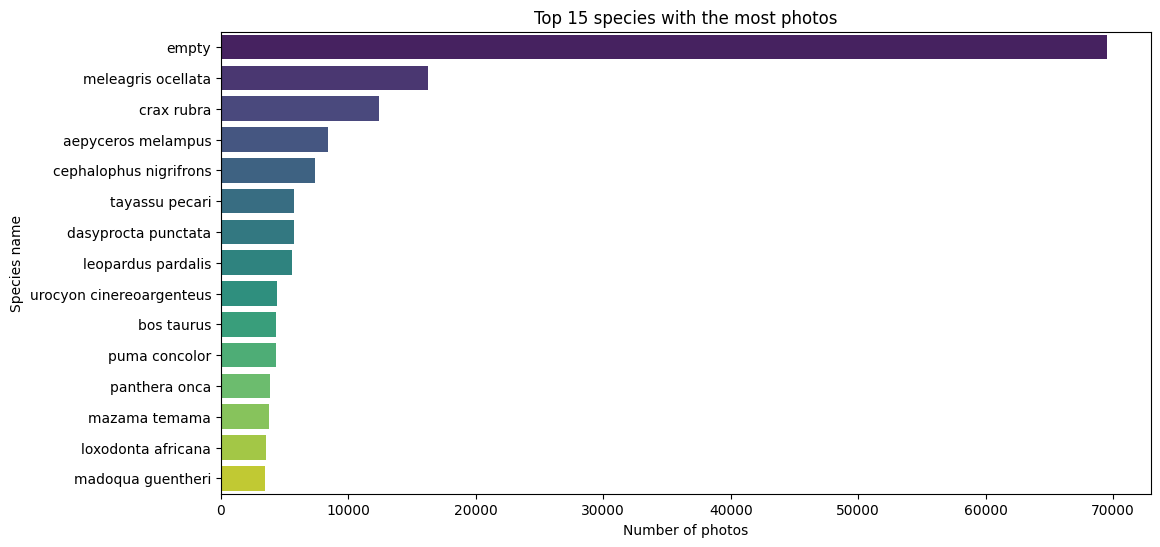

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

top_species = df_merged['name'].value_counts().head(15)
print("Top 15 most frequently occurring species:\n", top_species)

plt.figure(figsize=(12, 6))
sns.barplot(
    x=top_species.values, 
    y=top_species.index, 
    hue=top_species.index, 
    palette='viridis', 
    legend=False
)
plt.title('Top 15 species with the most photos')
plt.xlabel('Number of photos')
plt.ylabel('Species name')
plt.show()

In [12]:
top_locations = df_merged['location'].value_counts().head(10)
print("Locations where camera traps are most active.:\n", top_locations)

Locations where camera traps are most active.:
 location
501    8494
336    7600
408    4439
464    4010
105    3990
57     3960
256    3766
392    3722
526    3559
512    3550
Name: count, dtype: int64


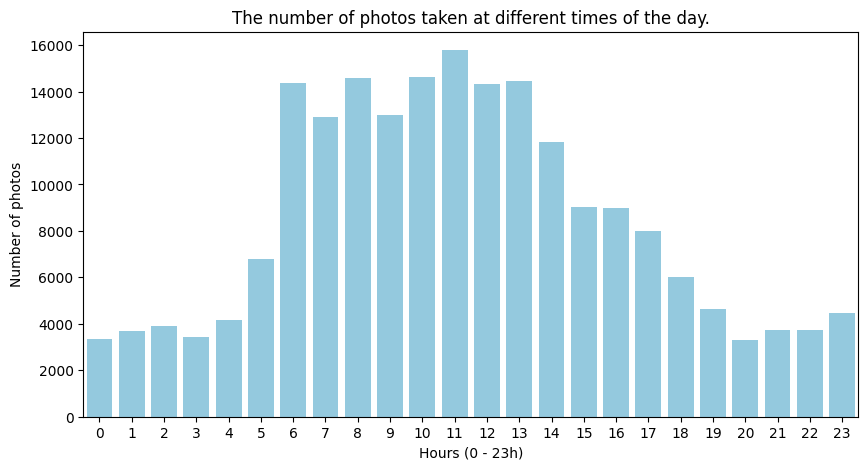

In [14]:
if 'datetime' in df_merged.columns:
    df_merged['datetime'] = pd.to_datetime(df_merged['datetime'])
    df_merged['hour'] = df_merged['datetime'].dt.hour
    
    plt.figure(figsize=(10, 5))
    sns.countplot(x='hour', data=df_merged, color='skyblue')
    plt.title('The number of photos taken at different times of the day.')
    plt.xlabel('Hours (0 - 23h)')
    plt.ylabel('Number of photos')
    plt.show()

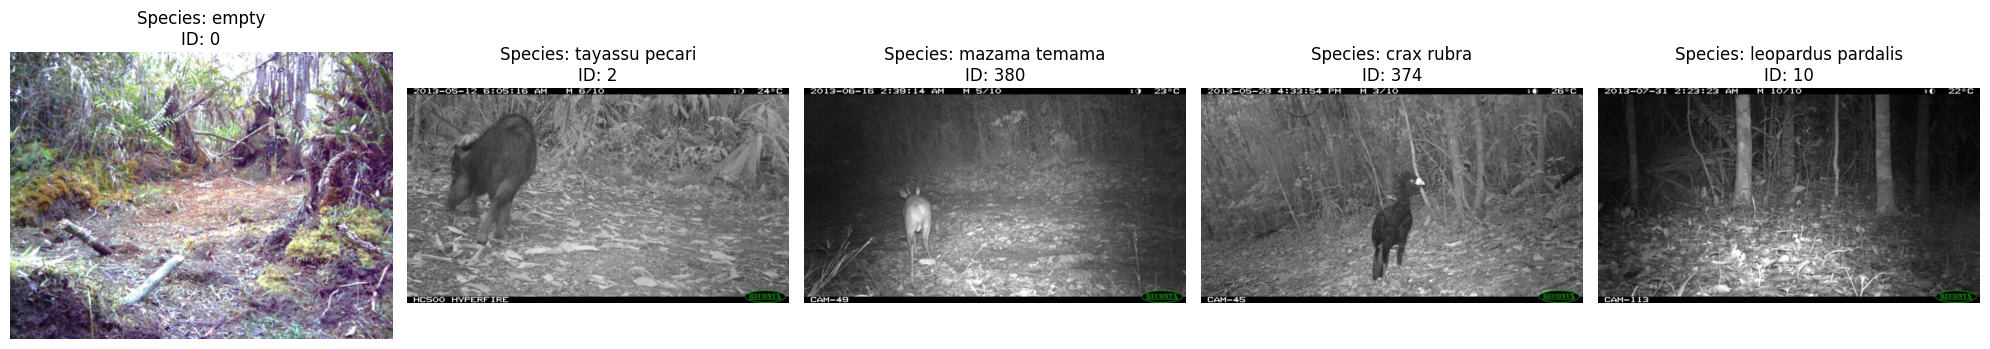

In [17]:
import cv2
import matplotlib.pyplot as plt

def show_images(df, num_images=4):
    sample_df = df.sample(num_images)
    
    fig, axes = plt.subplots(1, num_images, figsize=(20, 5))
    
    for i, (idx, row) in enumerate(sample_df.iterrows()):
        img_id = row['image_id']
        img_name = f"{img_id}.jpg" if not str(img_id).endswith('.jpg') else img_id
        img_path = f"/kaggle/input/datasets/tvnam2712/cauvangbanlaohac-iwildcam-v2/archive/train/{img_name}"
        
        img = cv2.imread(img_path)
        if img is not None:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            axes[i].imshow(img)
            axes[i].set_title(f"Species: {row.get('name', 'N/A')}\nID: {row['category_id']}")
            axes[i].axis('off')
        else:
            axes[i].text(0.5, 0.5, f"Not found\n{img_name}", ha='center', va='center')
            axes[i].axis('off')
            
    plt.tight_layout()
    plt.show()

show_images(df_merged, num_images=5)

In [20]:
empty_images = df_merged[df_merged['name'].str.lower().str.contains('empty', na=True)]

total_images = len(df_merged)
num_empty = len(empty_images)
empty_ratio = (num_empty / total_images) * 100

print(f"Total number of images in the dataset: {total_images}")
print(f"Number of blank photos (without animals): {num_empty} ({empty_ratio:.2f}%)")

Total number of images in the dataset: 203029
Number of blank photos (without animals): 69487 (34.23%)


In [25]:
from PIL import Image

df_sample = df_merged.sample(200, random_state=42)

widths = []
heights = []

for idx, row in df_sample.iterrows():
    img_id = row['image_id']
    img_name = f"{img_id}.jpg" if not str(img_id).endswith('.jpg') else img_id
    img_path = f"/kaggle/input/datasets/tvnam2712/cauvangbanlaohac-iwildcam-v2/archive/train/{img_name}"
    
    try:
        with Image.open(img_path) as img:
            w, h = img.size
            widths.append(w)
            heights.append(h)
    except:
        continue

df_sizes = pd.DataFrame({'Width': widths, 'Height': heights})
print("Sample image size statistics:")
print(df_sizes.describe())

print("\nThe most frequently appearing size pairs:")
print(df_sizes.value_counts().head())

Sample image size statistics:
            Width  Height
count  200.000000   200.0
mean   662.490000   448.0
std    103.528744     0.0
min    560.000000   448.0
25%    597.000000   448.0
50%    597.000000   448.0
75%    796.000000   448.0
max    796.000000   448.0

The most frequently appearing size pairs:
Width  Height
597    448       82
796    448       74
560    448       44
Name: count, dtype: int64


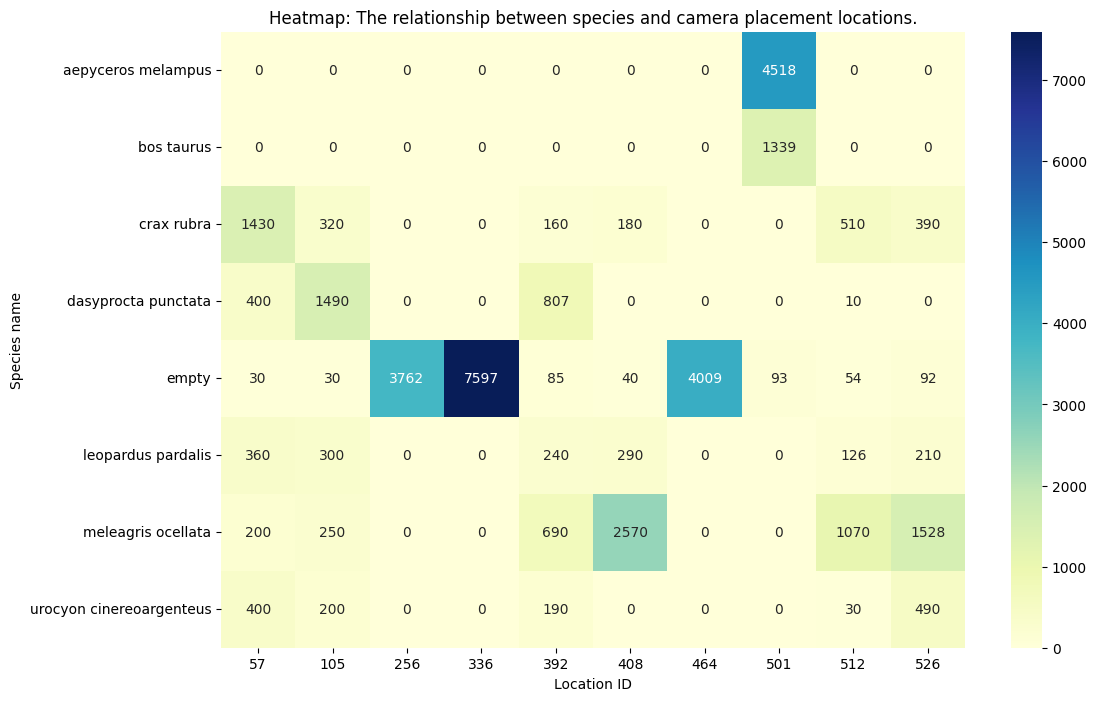

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create a frequency table between the Top 10 most photographed species and the Top 10 most photographed locations.
top_birds = df_merged['name'].value_counts().head(10).index
top_locs = df_merged['location'].value_counts().head(10).index

df_filtered = df_merged[df_merged['name'].isin(top_birds) & df_merged['location'].isin(top_locs)]

crosstab_res = pd.crosstab(df_filtered['name'], df_filtered['location'])

plt.figure(figsize=(12, 8))
sns.heatmap(crosstab_res, annot=True, fmt="d", cmap="YlGnBu", cbar=True)
plt.title("Heatmap: The relationship between species and camera placement locations.")
plt.ylabel("Species name")
plt.xlabel("Location ID")
plt.show()

The rarest species in the dataset.:
 name
myiophoneus caeruleus      1
chlorocebus pygerythrus    1
phaetornis sp              1
polyplectron chalcurum     1
leiothrix argentauris      1
Name: count, dtype: int64


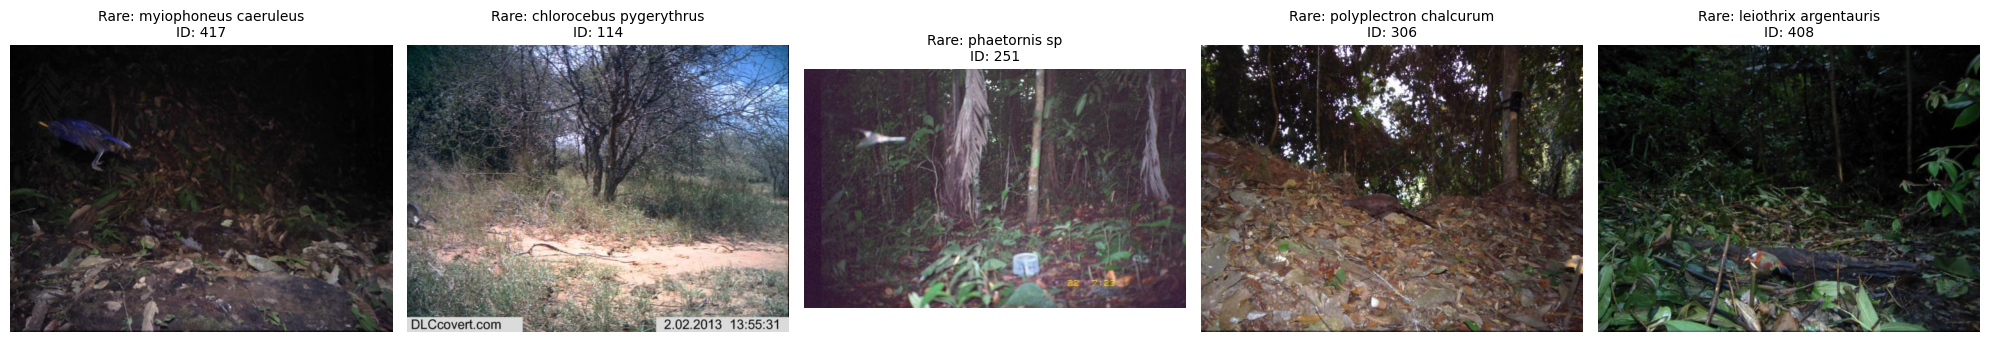

In [34]:
rare_species = df_merged['name'].value_counts().tail(5)
print("The rarest species in the dataset.:\n", rare_species)

fig, axes = plt.subplots(1, len(rare_species), figsize=(20, 5))

for i, species_name in enumerate(rare_species.index):
    rare_row = df_merged[df_merged['name'] == species_name].sample(1).iloc[0]
    img_id = rare_row['image_id']
    img_name = f"{img_id}.jpg" if not str(img_id).endswith('.jpg') else img_id
    img_path = f"/kaggle/input/datasets/tvnam2712/cauvangbanlaohac-iwildcam-v2/archive/train/{img_name}"
    
    img = cv2.imread(img_path)
    if img is not None:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        axes[i].imshow(img)
        axes[i].set_title(f"Rare: {species_name}\nID: {rare_row['category_id']}", fontsize=10)
        axes[i].axis('off')
    else:
        axes[i].text(0.5, 0.5, f"Cannot open\n{img_name}", ha='center', va='center')
        axes[i].axis('off')

plt.tight_layout()
plt.show()

In [38]:
df_merged.to_csv('/kaggle/working/df_merged.csv', index=False)

